# 直方图

## 条形图和直方图

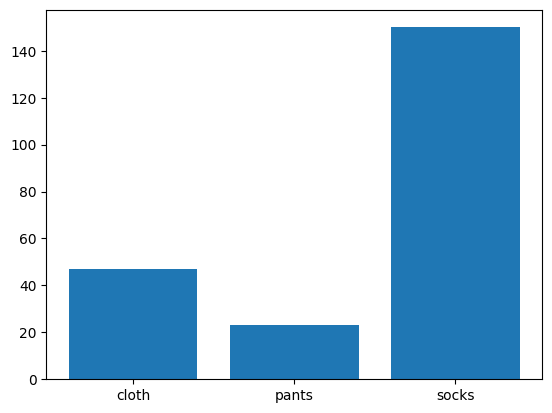

In [56]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['cloth', 'pants', 'socks']
values = [47, 23, 150]
plt.bar(categories, values)
plt.show()

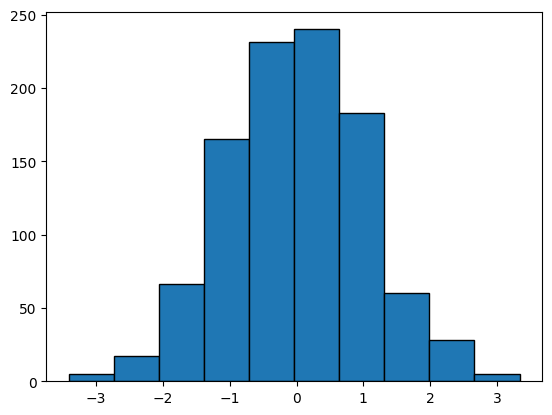

In [71]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(np.random.randn(1000), edgecolor='k')
plt.show()

## bins, density, weights参数

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


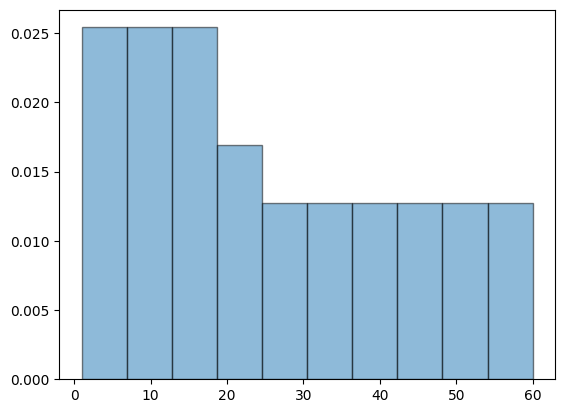

In [79]:
import numpy as np
import matplotlib.pyplot as plt

other_params = {
    'edgecolor': 'black',
    'alpha': 0.5
}

values = np.arange(1, 61)
data = np.repeat(values, 5)
# print(len(data))
# print(data)

# np.random.shuffle(data)

weights = np.ones(300)
weights[:100] = 2
print(weights)

plt.hist(data, bins=10, density=True, weights=weights, **other_params)
plt.show()

# 参数密度估计

mean 20.192978696780443, std 5.061210874599355
fit mean 20.192978696780443, fit std 5.061210874599355


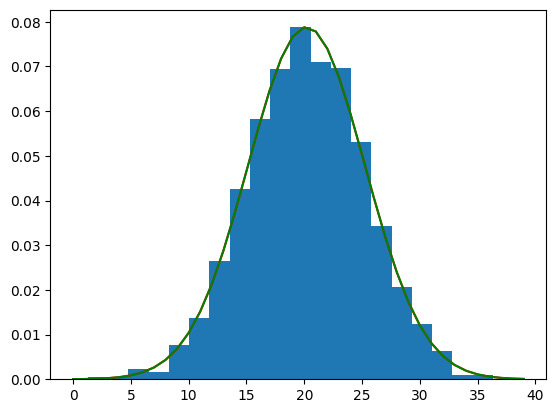

In [160]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

sample = np.random.normal(loc=20, scale=5, size=2000)
sample_mean = np.mean(sample)
sample_std = np.std(sample)
print(f'mean {sample_mean}, std {sample_std}')
plt.hist(sample, bins=20, density=True)

x = [value for value in range(0, 40)]

dist = scipy.stats.norm(sample_mean, sample_std)
plt.plot(x, dist.pdf(x), color='r')

fit_loc, fit_scale = scipy.stats.norm.fit(sample)
print(f'fit mean {fit_loc}, fit std {fit_scale}')
fit_dist = scipy.stats.norm(fit_loc, fit_scale)
plt.plot(x, fit_dist.pdf(x), color='g')

plt.show()

est. loc 0.019255954552862088, scale 3.9151204442956065


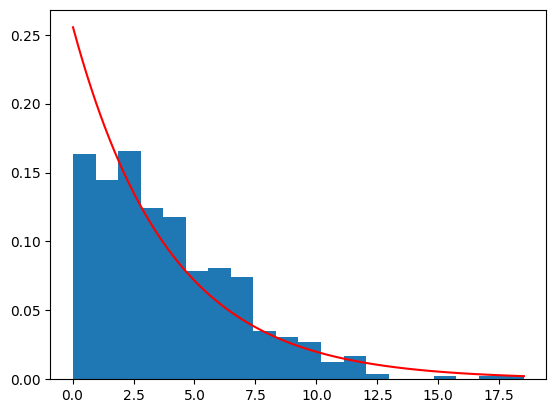

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

sample = np.random.normal(loc=0, scale=5, size=1000)
data = sample[sample > 0]
plt.hist(data, bins=20, density=True)

loc, scale = expon.fit(data)
print(f'est. loc {loc}, scale {scale}')

x = np.linspace(min(data), max(data), 100)
pdf_fitted = expon.pdf(x, loc, scale)
plt.plot(x, pdf_fitted, 'r-')

plt.show()


# 核密度估计

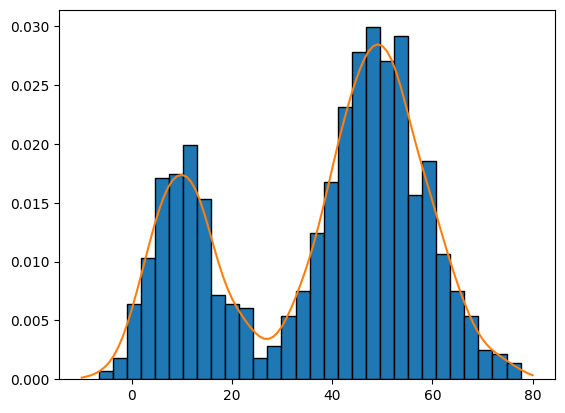

In [79]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KernelDensity
from scipy.stats import norm

np.random.seed(0)

sample1 = np.random.normal(loc=10, scale=6, size=300)
sample2 = np.random.normal(loc=50, scale=10, size=700)
# sample = np.hstack((sample1, sample2))
sample = np.concatenate((sample1, sample2))

plt.hist(sample, bins=30, edgecolor='k', density=True)

sample = sample.reshape((len(sample), 1))


model = KernelDensity(bandwidth=3, kernel='gaussian')
model.fit(sample)

x = np.linspace(-10, 80, 100)
x = x.reshape((len(x), 1))
density = model.score_samples(x)
density = np.exp(density)

plt.plot(x[:], density)
plt.show()

MISE: Mean Integrated Squared Error

MISE: 1.2955953510927739e-05


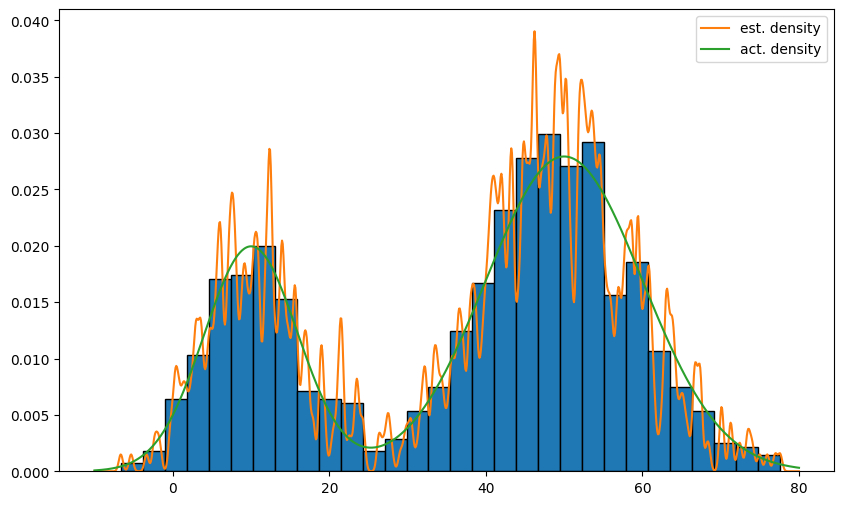

In [5]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KernelDensity
from scipy.stats import norm

num_samples = 1000
mu1, sigma1, w1 = 10, 6, 0.3
mu2, sigma2, w2 = 50, 10, 0.7

def mix_pdf(x):
    return w1 * norm.pdf(x, loc=mu1, scale=sigma1) + w2 * norm.pdf(x, loc=mu2, scale=sigma2)

plt.figure(figsize=(10, 6))

np.random.seed(0)

sample1 = np.random.normal(loc=mu1, scale=sigma1, size=int(w1 * num_samples))
sample2 = np.random.normal(loc=mu2, scale=sigma2, size=int(w2 * num_samples))
sample = np.concatenate((sample1, sample2))

plt.hist(sample, bins=30, edgecolor='k', density=True)

sample = sample.reshape((len(sample), 1))


# model = KernelDensity(bandwidth=20, kernel='gaussian')
model = KernelDensity(bandwidth='silverman', kernel='gaussian')
model.fit(sample)

x = np.linspace(-10, 80, 1000)
density = model.score_samples(x.reshape((len(x), 1)))
density = np.exp(density)

plt.plot(x, density, label='est. density')

actual_density = mix_pdf(x)
plt.plot(x, actual_density, label='act. density')

print(f'MISE: {np.mean((density - actual_density) ** 2)}')

plt.legend()
plt.show()